# setup_data.py

In [ ]:
!pip install osmnx

In [ ]:
# setup_data.py
# Однократная загрузка дорожной сети, геокодирование складов, анализ датасета,
# привязка складов к графу и построение асимметричной матрицы расстояний.
# Сохраняет все результаты в папку raw_data/ и создаёт архив для Colab.

import os
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import requests
import pandas as pd
import numpy as np
import time
import json
import warnings
from collections import Counter
from math import radians, sin, cos, sqrt, atan2
warnings.filterwarnings('ignore')

# импорт функции архивации
from utils import zip_folder

In [ ]:
# Конфигурация
YANDEX_API_KEY = "2b53a0d9-55d7-4f1c-a255-e1b252cbd2fb"
OUTPUT_DIR = "raw_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Глобальные настройки OSMnx
ox.settings.log_console = True
ox.settings.use_cache = True
ox.settings.timeout = 300

In [ ]:
# 1. Скачивание дорожной сети
def download_moscow_region_graph(show_plots=True):
    """
    Скачивает ориентированный граф автомобильных дорог Москвы и Московской области.
    Сохраняет в OUTPUT_DIR/moscow_region_drive_network.graphml.
    """
    print("Получаем границы Москвы и Московской области")
    places = ["Москва, Россия", "Московская область, Россия"]
    regions_gdf = ox.geocode_to_gdf(places)

    if show_plots:
        fig, ax = plt.subplots(figsize=(10, 10))
        regions_gdf.plot(ax=ax, fc="gray", ec="blue", alpha=0.5)
        ax.set_title("Границы Москвы и Московской области")
        ax.axis("off")
        plt.show()

    combined_polygon = regions_gdf.unary_union

    print("Скачиваем дорожную сеть (только drive)")
    graph = ox.graph_from_polygon(
        combined_polygon,
        network_type='drive',
        simplify=True
    )

    output_file = os.path.join(OUTPUT_DIR, "moscow_region_drive_network.graphml")
    ox.save_graphml(graph, output_file)
    print(f"Граф сохранён как '{output_file}'")
    print(f"Количество узлов: {graph.number_of_nodes()}, рёбер: {graph.number_of_edges()}")
    return graph

In [ ]:
# 2. Анализ дорожной сети
def analyze_road_network(graph):
    """Выводит подробную статистику о дорожной сети и сохраняет графики."""
    print("Анализ дорожной сети")

    n_nodes = graph.number_of_nodes()
    n_edges = graph.number_of_edges()
    print(f"Количество перекрёстков (узлов): {n_nodes:,}")
    print(f"Количество дорожных сегментов (рёбер): {n_edges:,}")
    print(f"Плотность сети: {nx.density(graph):.6f}")

    # Анализ типов дорог
    highway_types = []
    road_lengths = {}
    oneway_count = 0
    for u, v, data in graph.edges(data=True):
        hw = data.get('highway', 'unknown')
        length = data.get('length', 0)
        if data.get('oneway', False):
            oneway_count += 1
        if isinstance(hw, list):
            for h in hw:
                highway_types.append(h)
                road_lengths[h] = road_lengths.get(h, 0) + length
        else:
            highway_types.append(hw)
            road_lengths[hw] = road_lengths.get(hw, 0) + length

    total_edges = len(highway_types)
    total_length_km = sum(road_lengths.values()) / 1000
    print(f"\nВсего дорожных сегментов: {total_edges:,}")
    print(f"Общая длина дорог: {total_length_km:,.1f} км")
    print(f"Односторонних дорог: {oneway_count} ({oneway_count/total_edges*100:.1f}%)")

    type_counts = Counter(highway_types)
    print("\nТоп-10 типов дорог по количеству:")
    for hw, cnt in type_counts.most_common(10):
        print(f"  {hw:20}: {cnt:6} сегментов ({cnt/total_edges*100:5.1f}%)")

    print("\nТоп-10 типов дорог по длине:")
    for hw in sorted(road_lengths.keys(), key=lambda x: road_lengths[x], reverse=True)[:10]:
        len_km = road_lengths[hw] / 1000
        pct = road_lengths[hw] / sum(road_lengths.values()) * 100
        print(f"  {hw:20}: {len_km:8.1f} км ({pct:5.1f}%)")

    # Статистика длин рёбер
    lengths = [data.get('length', 0) for u, v, data in graph.edges(data=True)]
    if lengths:
        print(f"\nДлины дорожных сегментов (метры):")
        print(f"  Средняя: {np.mean(lengths):.1f} м")
        print(f"  Медиана: {np.median(lengths):.1f} м")
        print(f"  Мин/Макс: {np.min(lengths):.1f} / {np.max(lengths):.1f} м")
        print(f"  Стд. откл.: {np.std(lengths):.1f} м")

    # Степени узлов
    degrees = [d for n, d in graph.degree()]
    print(f"\nСтепени узлов (количество примыкающих дорог):")
    print(f"  Средняя: {np.mean(degrees):.2f}")
    print(f"  Мин/Макс: {np.min(degrees)} / {np.max(degrees)}")

    # Связность
    print(f"\nГраф сильно связный: {nx.is_strongly_connected(graph)}")
    scc = list(nx.strongly_connected_components(graph))
    print(f"Количество компонент сильной связности: {len(scc)}")
    if len(scc) > 1:
        sizes = [len(c) for c in scc]
        print(f"  Размеры крупнейших: {sorted(sizes, reverse=True)[:5]}")

    # Проверка асимметрии на случайных парах
    print("\nПроверка асимметрии (5 случайных пар узлов):")
    nodes_list = list(graph.nodes)
    np.random.seed(42)
    sample = np.random.choice(nodes_list, size=min(10, len(nodes_list)), replace=False)
    asym_count = 0
    for i in range(0, len(sample)-1, 2):
        u, v = sample[i], sample[i+1]
        try:
            d_uv = nx.shortest_path_length(graph, u, v, weight='length')
            d_vu = nx.shortest_path_length(graph, v, u, weight='length')
            diff = abs(d_uv - d_vu)
            if diff > 1.0:
                asym_count += 1
            print(f"  {u} -> {v}: {d_uv/1000:.2f} км, обратно: {d_vu/1000:.2f} км (разница {diff:.1f} м)")
        except nx.NetworkXNoPath:
            print(f"  Нет пути между {u} и {v}")
    print(f"  Асимметричных пар: {asym_count} из {len(sample)//2}")

    # Визуализация дорожной сети по категориям
    fig, ax = plt.subplots(figsize=(15, 12))
    edge_colors = []
    for u, v, data in graph.edges(data=True):
        hw = data.get('highway', 'other')
        if isinstance(hw, list):
            hw = hw[0] if hw else 'other'
        if hw in ['motorway', 'trunk', 'primary', 'secondary']:
            edge_colors.append('red')
        elif hw in ['tertiary', 'unclassified', 'residential']:
            edge_colors.append('blue')
        elif hw in ['service', 'living_street']:
            edge_colors.append('green')
        else:
            edge_colors.append('gray')
    ox.plot_graph(graph, ax=ax, node_size=0, edge_color=edge_colors,
                  edge_linewidth=0.5, bgcolor='white', show=False, close=False)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, label='Основные (motorway/trunk/primary)'),
        Line2D([0], [0], color='blue', lw=2, label='Местные (tertiary/residential)'),
        Line2D([0], [0], color='green', lw=2, label='Служебные (service)'),
        Line2D([0], [0], color='gray', lw=2, label='Прочие')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_title("Дорожная сеть Московского региона (по категориям)", fontsize=14)
    plt.tight_layout()
    map_path = os.path.join(OUTPUT_DIR, "road_network_categories.png")
    plt.savefig(map_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Карта дорожной сети сохранена: {map_path}")

    return total_length_km

In [ ]:
# 3. Геокодирование складов
def geocode_yandex(address, api_key):
    base_url = "https://geocode-maps.yandex.ru/1.x/"
    params = {"apikey": api_key, "geocode": address, "format": "json", "lang": "ru_RU"}
    try:
        print(f"Геокодируем: {address}")
        response = requests.get(base_url, params=params, timeout=10)
        data = response.json()
        found = data['response']['GeoObjectCollection']['metaDataProperty']['GeocoderResponseMetaData']['found']
        if int(found) > 0:
            pos = data['response']['GeoObjectCollection']['featureMember'][0]['GeoObject']['Point']['pos']
            lon, lat = map(float, pos.split())
            print(f"Найдено: {lat}, {lon}")
            return lat, lon
        else:
            print(f"Не найдено: {address}")
            return None, None
    except Exception as e:
        print(f"Ошибка геокодирования {address}: {e}")
        return None, None

def save_to_json(df, filename):
    records = []
    for _, row in df.iterrows():
        records.append({
            'name': row['name'],
            'address': row['address'],
            'latitude': row['latitude'],
            'longitude': row['longitude']
        })
    path = os.path.join(OUTPUT_DIR, filename)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print(f"Сохранён файл: {path}")

def geocode_warehouses(show_plots=True):
    """
    Геокодирует РЦ/РФЦ (12) и сортировочные центры (17).
    Возвращает DataFrame.
    """
    # РЦ/РФЦ
    warehouses_data = [
        {"name": "ПАВЛО_СЛОБОДСКОЕ_РЦ", "address": "143581, Московская обл., Истринский район, с. Павловская Слобода, территория квартала 0050343, зд. 2"},
        {"name": "ХОРУГВИНО_РФЦ", "address": "141533, Московская обл., Солнечногорский р-н, с.п. Пешковское, дер. Хоругвино, стр. 32/2"},
        {"name": "Новая_Рига_РФЦ", "address": "Московская область, муниципальный округ Истра, территория МПСК Ориентир-Запад, 1Б"},
        {"name": "Жуковский", "address": "140182, Московская область, г. Жуковский, район Замоскворечье, д. 457, стр. 5"},
        {"name": "Софьино", "address": "Российская Федерация, Московская область, Раменский городской округ, квартал 4/218, стр. 2/1"},
        {"name": "Ногинск", "address": "142440, РФ, МО, Богородский городской округ, р.п. Обухово, тер. Обухово-Парк, дом 2, строение 1"},
        {"name": "Гривно", "address": "142184, МО, г.о. Подольск, д. Гривно, тер. пром. парка Гривно, д. 1, к. 13"},
        {"name": "Пушкино-1", "address": "Россия, Московская область, Пушкинский городской округ, г. Пушкино, Ярославское шоссе, д. 216"},
        {"name": "Пушкино-2", "address": "Россия, Московская область, г.о. Пушкинский, г. Пушкино, Ярославское шоссе, д. 218"},
        {"name": "Радумля_РФЦ", "address": "посёлок городского типа Радумля, с2, городской округ Солнечногорск, Московская область"},
        {"name": "Домодедово_РФЦ", "address": "деревня Кучино, 52, городской округ Домодедово, Московская область"},
        {"name": "Ватутинки_РФЦ", "address": "Нововатутинский проспект, 13, Москва, район Троицк"}
    ]
    warehouses_df = pd.DataFrame(warehouses_data)
    print("Геокодирование РЦ/РФЦ (12 шт.)")
    coords = []
    for addr in warehouses_df['address']:
        lat, lon = geocode_yandex(addr, YANDEX_API_KEY)
        coords.append((lat, lon))
        time.sleep(0.5)
    warehouses_df['latitude'] = [c[0] for c in coords]
    warehouses_df['longitude'] = [c[1] for c in coords]
    warehouses_df = warehouses_df.dropna(subset=['latitude', 'longitude'])
    save_to_json(warehouses_df, "warehouses_rc_rfc_coordinates.json")

    # Сортировочные центры
    sorting_centers_data = [
        {"name": "Анненский", "address": "г. Москва, Анненский проезд, д. 3, стр. 1"},
        {"name": "Варшавская", "address": "г. Москва, 1-й Варшавский пр-д, д. 2, стр. 9А"},
        {"name": "Железнодорожный", "address": "обл. Московская, г. Балашиха, д. Пестово, д. 14А"},
        {"name": "Истра", "address": "Московская обл., г. Истра, д. Давыдовское, ул. Дачная, стр. 3"},
        {"name": "Королев", "address": "Московская обл., г. Королев, ул. Силикатная, д. 10А"},
        {"name": "Огуднево", "address": "Московская область, городской округ Щёлково, деревня Огуднево, ул. Полевая, д. 1/1"},
        {"name": "Щербинка", "address": "обл. Московская, г. Подольск, д. Борисовка, пром. зона ПромТехАльянс, д. 1, стр. 2"},
        {"name": "Челобитьево", "address": "г. Мытищи, д. Челобитьево, Осташковское шоссе, владение 15, стр. 1"},
        {"name": "Нижнее Велино", "address": "обл. Московская, р-н Раменский, д. Нижнее Велино, ш. Старо-Рязанское, корпус 2, стр. 2"},
        {"name": "Воровского", "address": "Московская область, р.п. имени Воровского, ул. Мира, д. 5, склад 16"},
        {"name": "Львовский (ТСЦ)", "address": "142155, обл. Московская, г. Подольск, пром. зона Львовский, ул. Московская, д. 69, стр. 5"},
        {"name": "Химки", "address": "141401, обл. Московская, г. Химки, пр-д Коммунальный, 30А, стр. 1"},
        {"name": "Сухарево", "address": "Московская обл., Городской округ Мытищи, д. Сухарево, д. 135"},
        {"name": "Чёрная Грязь", "address": "Московская обл., Солнечногорский р-н, дер. Черная Грязь, ул. Сходненская, стр. 1"},
        {"name": "Саларьево", "address": "г. Москва, пос. Московский, д. Саларьево, владение 7, стр. 1"},
        {"name": "МКШВ", "address": "г. Москва, ул. Рябиновая, д. 44, стр. 28"},
        {"name": "Скотопрогонная", "address": "г. Москва, ул. Скотопрогонная, д. 35, стр. 3"}
    ]
    sorting_df = pd.DataFrame(sorting_centers_data)
    print("\nГеокодирование сортировочных центров (17 шт.)")
    coords_sc = []
    for addr in sorting_df['address']:
        lat, lon = geocode_yandex(addr, YANDEX_API_KEY)
        coords_sc.append((lat, lon))
        time.sleep(0.5)
    sorting_df['latitude'] = [c[0] for c in coords_sc]
    sorting_df['longitude'] = [c[1] for c in coords_sc]
    sorting_df = sorting_df.dropna(subset=['latitude', 'longitude'])
    save_to_json(sorting_df, "sorting_centers_coordinates.json")

    # Объединённый файл
    all_df = pd.concat([warehouses_df, sorting_df], ignore_index=True)
    save_to_json(all_df, "all_warehouses_coordinates.json")
    print(f"\nГеокодирование завершено. Всего складов: {len(all_df)}")
    return warehouses_df, sorting_df, all_df

In [ ]:
# 4. Привязка к графу и анализ подключения
def calculate_geodesic_distance(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def analyze_warehouse_connection(graph, warehouse_df):
    """Привязывает склады к узлам графа и анализирует качество подключения."""
    warehouse_nodes = []
    print("\nПривязка складов к узлам графа:")
    for idx, row in warehouse_df.iterrows():
        point = (row['latitude'], row['longitude'])
        node = ox.distance.nearest_nodes(graph, point[1], point[0])
        warehouse_nodes.append(node)
        node_data = graph.nodes[node]
        dist = calculate_geodesic_distance(point[0], point[1], node_data['y'], node_data['x'])
        # Количество примыкающих дорог
        num_edges = len(list(graph.neighbors(node)))
        if dist <= 200 and num_edges >= 2:
            quality = "ХОРОШЕЕ"
        elif dist <= 500 and num_edges >= 1:
            quality = "СРЕДНЕЕ"
        else:
            quality = "ПЛОХОЕ"
        print(f"  {row['name']:25} -> узел {node}, расстояние {dist:.1f} м, {num_edges} дорог ({quality})")
    warehouse_df['node_id'] = warehouse_nodes
    return warehouse_df, warehouse_nodes

def check_warehouses_accessibility(graph, warehouse_nodes, names):
    print("\nПроверка достижимости складов:")
    n = len(warehouse_nodes)
    unreachable = []
    for i in range(n):
        for j in range(n):
            if i == j: continue
            try:
                nx.shortest_path_length(graph, warehouse_nodes[i], warehouse_nodes[j], weight='length')
            except nx.NetworkXNoPath:
                unreachable.append((names[i], names[j]))
    if unreachable:
        print(f"  Найдено {len(unreachable)} недостижимых пар.")
        for u, v in unreachable[:5]:
            print(f"    {u} -> {v}")
    else:
        print("  Все склады достижимы.")

In [ ]:
# 5. Построение матрицы расстояний
def compute_asymmetric_distance_matrix(graph, warehouse_nodes):
    n = len(warehouse_nodes)
    D = np.full((n, n), 1e9, dtype=np.float32)
    for i in range(n):
        for j in range(n):
            if i == j:
                D[i][j] = 0.0
            else:
                try:
                    d = nx.shortest_path_length(graph, warehouse_nodes[i], warehouse_nodes[j], weight='length')
                    D[i][j] = float(d)
                except nx.NetworkXNoPath:
                    pass
    return D

In [ ]:
# 6. Визуализация складов на фоне дорожной сети
def plot_warehouses_on_graph(graph, warehouses_df, title, colors, save_path):
    fig, ax = plt.subplots(figsize=(15, 12))
    ox.plot_graph(graph, ax=ax, node_size=0, edge_color='lightgray',
                  edge_linewidth=0.5, bgcolor='white', show=False, close=False)
    if isinstance(colors, str):
        ax.scatter(warehouses_df['longitude'], warehouses_df['latitude'],
                   c=colors, s=100, edgecolors='black', linewidth=1.5)
    else:
        ax.scatter(warehouses_df['longitude'], warehouses_df['latitude'],
                   c=colors, s=100, edgecolors='black', linewidth=1.5)
    for idx, row in warehouses_df.iterrows():
        short_name = row['name'][:15] + '...' if len(row['name']) > 15 else row['name']
        ax.annotate(short_name, (row['longitude'], row['latitude']),
                    xytext=(5,5), textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Карта сохранена: {save_path}")

Загружаем существующий граф: raw_data/moscow_region_drive_network.graphml
Анализ дорожной сети
Количество перекрёстков (узлов): 182,681
Количество дорожных сегментов (рёбер): 443,844
Плотность сети: 0.000013

Всего дорожных сегментов: 452,357
Общая длина дорог: 130,519.7 км
Односторонних дорог: 36558 (8.1%)

Топ-10 типов дорог по количеству:
  residential         : 236741 сегментов ( 52.3%)
  unclassified        : 109827 сегментов ( 24.3%)
  tertiary            :  47511 сегментов ( 10.5%)
  secondary           :  28680 сегментов (  6.3%)
  primary             :  10143 сегментов (  2.2%)
  living_street       :   7649 сегментов (  1.7%)
  trunk               :   5332 сегментов (  1.2%)
  secondary_link      :   2470 сегментов (  0.5%)
  tertiary_link       :   1764 сегментов (  0.4%)
  primary_link        :   1046 сегментов (  0.2%)

Топ-10 типов дорог по длине:
  residential         :  53096.5 км ( 40.7%)
  unclassified        :  39138.3 км ( 30.0%)
  tertiary            :  17356.6 км 

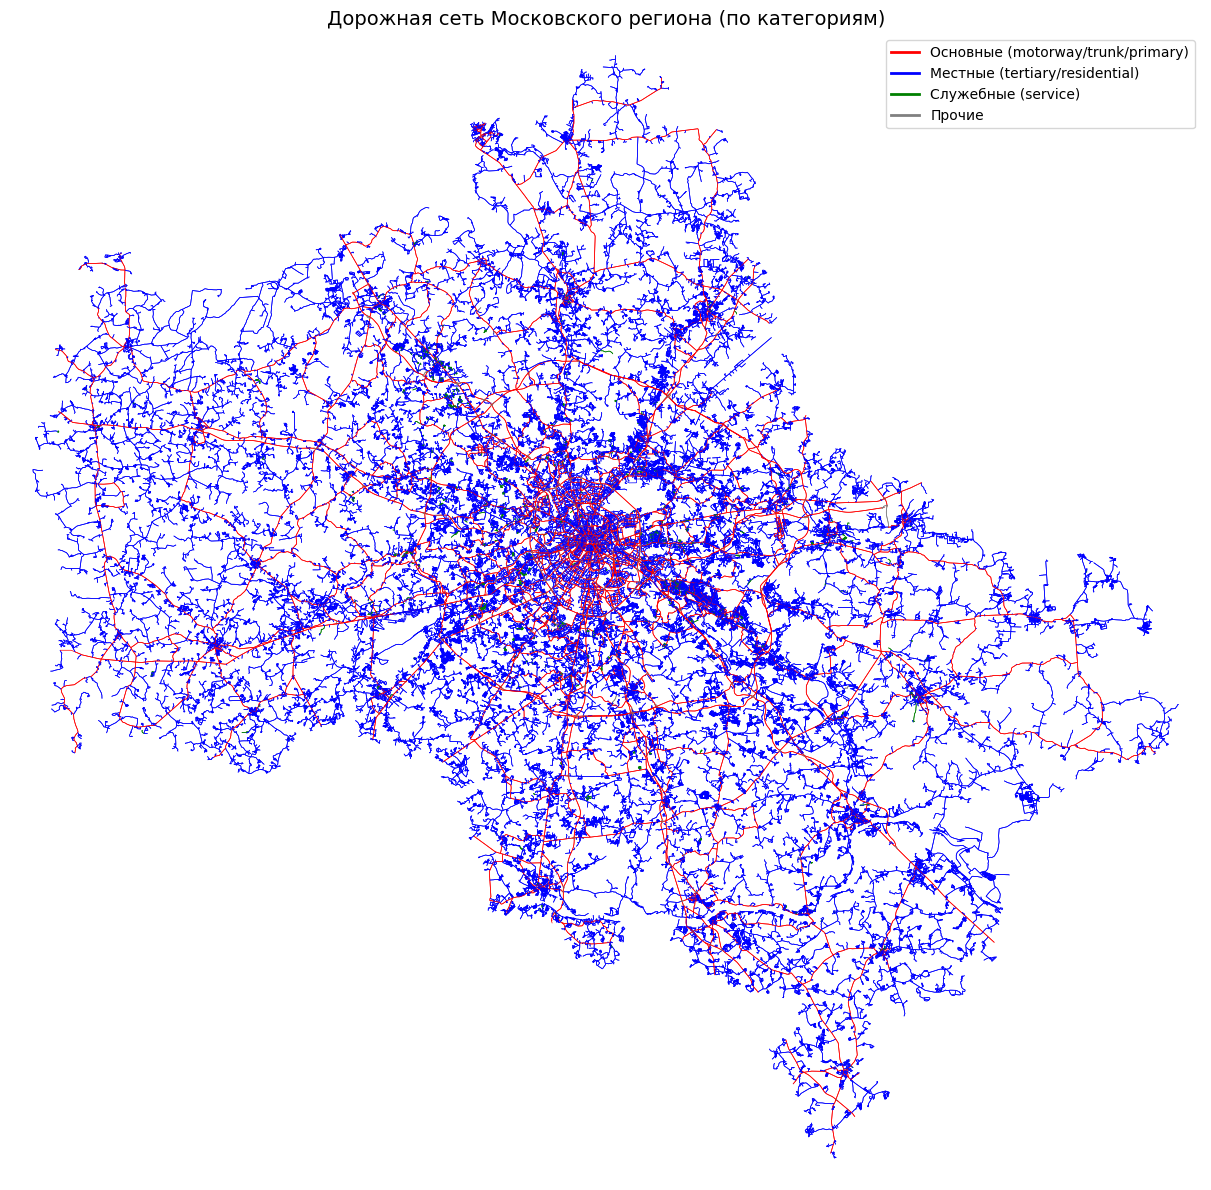

Карта дорожной сети сохранена: raw_data/road_network_categories.png
Геокодирование РЦ/РФЦ (12 шт.)
Геокодируем: 143581, Московская обл., Истринский район, с. Павловская Слобода, территория квартала 0050343, зд. 2
Найдено: 55.810284, 37.086758
Геокодируем: 141533, Московская обл., Солнечногорский р-н, с.п. Пешковское, дер. Хоругвино, стр. 32/2
Найдено: 56.124145, 37.209279
Геокодируем: Московская область, муниципальный округ Истра, территория МПСК Ориентир-Запад, 1Б
Найдено: 55.833142, 36.875878
Геокодируем: 140182, Московская область, г. Жуковский, район Замоскворечье, д. 457, стр. 5
Найдено: 55.569611, 38.068464
Геокодируем: Российская Федерация, Московская область, Раменский городской округ, квартал 4/218, стр. 2/1
Найдено: 55.362357, 38.206544
Геокодируем: 142440, РФ, МО, Богородский городской округ, р.п. Обухово, тер. Обухово-Парк, дом 2, строение 1
Найдено: 55.829355, 38.247741
Геокодируем: 142184, МО, г.о. Подольск, д. Гривно, тер. пром. парка Гривно, д. 1, к. 13
Найдено: 55.3508

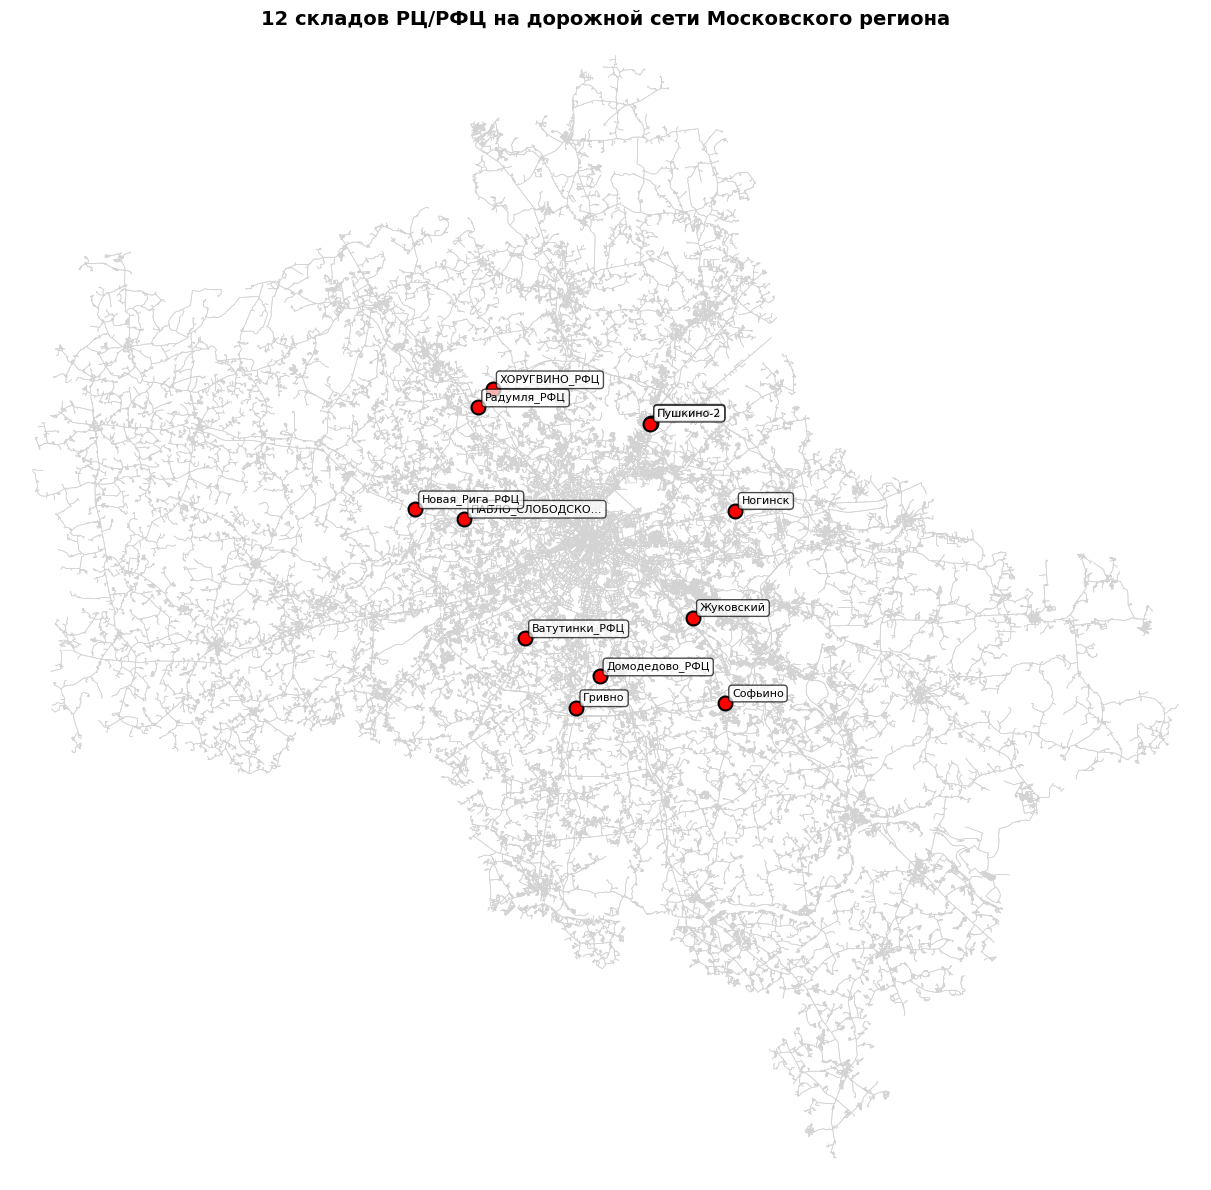

Карта сохранена: raw_data/warehouses_12_on_roads.png


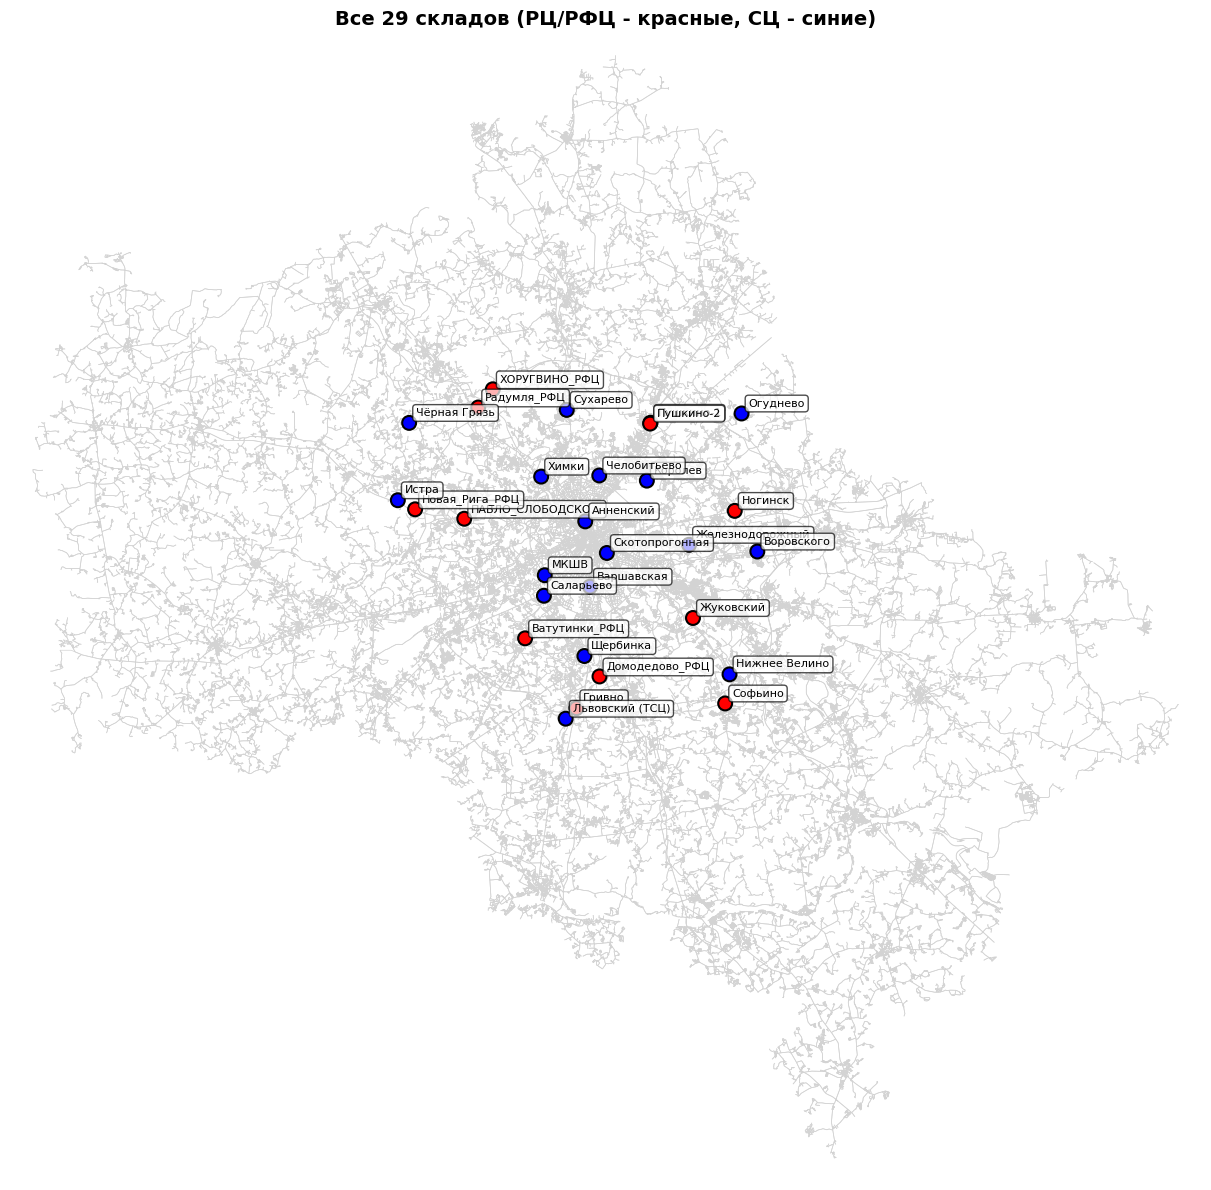

Карта сохранена: raw_data/warehouses_all_on_roads.png
Папка raw_data заархивирована в raw_data.zip

Архив создан: raw_data.zip


In [ ]:
# 7. Точка входа
if __name__ == "__main__":
    SHOW_PLOTS = True

    # 1. Загрузка / скачивание графа
    graph_path = os.path.join(OUTPUT_DIR, "moscow_region_drive_network.graphml")
    if not os.path.exists(graph_path):
        graph = download_moscow_region_graph(show_plots=SHOW_PLOTS)
    else:
        print(f"Загружаем существующий граф: {graph_path}")
        graph = ox.load_graphml(graph_path)

    # 2. Анализ дорожной сети
    total_road_km = analyze_road_network(graph)

    # 3. Геокодирование складов (если JSON ещё нет)
    rc_json = os.path.join(OUTPUT_DIR, "warehouses_rc_rfc_coordinates.json")
    if not os.path.exists(rc_json):
        warehouses_df, sorting_df, all_df = geocode_warehouses(show_plots=SHOW_PLOTS)
    else:
        print("JSON-файлы со складами уже существуют, загружаем их.")
        with open(rc_json, 'r', encoding='utf-8') as f:
            warehouses_df = pd.DataFrame(json.load(f))
        with open(os.path.join(OUTPUT_DIR, "sorting_centers_coordinates.json"), 'r', encoding='utf-8') as f:
            sorting_df = pd.DataFrame(json.load(f))
        with open(os.path.join(OUTPUT_DIR, "all_warehouses_coordinates.json"), 'r', encoding='utf-8') as f:
            all_df = pd.DataFrame(json.load(f))

    # 4. Привязка складов к графу и анализ подключения (только для 12 РЦ/РФЦ)
    print("Анализ подключения складов (РЦ/РФЦ)")
    warehouses_df, warehouse_nodes = analyze_warehouse_connection(graph, warehouses_df)
    check_warehouses_accessibility(graph, warehouse_nodes, warehouses_df['name'].tolist())

    # 5. Построение асимметричной матрицы расстояний
    print("Построение асимметричной матрицы расстояний")
    dist_matrix = compute_asymmetric_distance_matrix(graph, warehouse_nodes)
    diff = np.abs(dist_matrix - dist_matrix.T)
    max_diff = np.max(diff)
    asym_pairs = np.sum(diff > 1.0)
    total_pairs = dist_matrix.size - dist_matrix.shape[0]
    print(f"Максимальная разница (туда-обратно): {max_diff:.1f} м")
    print(f"Асимметричных пар: {asym_pairs} из {total_pairs} ({asym_pairs/total_pairs*100:.1f}%)")
    matrix_path = os.path.join(OUTPUT_DIR, "distance_matrix_Без_шума.npy")
    np.save(matrix_path, dist_matrix)
    print(f"Матрица сохранена: {matrix_path}")

    # 6. Визуализация складов на фоне дорог
    print("Визуализация складов")
    # 12 складов
    plot_warehouses_on_graph(
        graph, warehouses_df,
        "12 складов РЦ/РФЦ на дорожной сети Московского региона",
        'red',
        os.path.join(OUTPUT_DIR, "warehouses_12_on_roads.png")
    )
    # 29 складов
    colors = ['red'] * len(warehouses_df) + ['blue'] * len(sorting_df)
    plot_warehouses_on_graph(
        graph, all_df,
        "Все 29 складов (РЦ/РФЦ - красные, СЦ - синие)",
        colors,
        os.path.join(OUTPUT_DIR, "warehouses_all_on_roads.png")
    )

    # 7. Архивация папки
    if zip_folder is not None:
        zip_path = zip_folder(OUTPUT_DIR)
        print(f"\nАрхив создан: {zip_path}")
    else:
        print("\nФункция архивации не найдена.")

In [ ]:
import osmnx as ox
import networkx as nx
import json
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

def geodesic_distance(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Загрузка графа
graph = ox.load_graphml("raw_data/moscow_region_drive_network.graphml")

# Загрузка всех 29 складов
with open("raw_data/all_warehouses_coordinates.json", "r", encoding="utf-8") as f:
    warehouses = json.load(f)

results = []
for w in warehouses:
    lat, lon = w['latitude'], w['longitude']
    node = ox.distance.nearest_nodes(graph, lon, lat)
    node_data = graph.nodes[node]
    dist = geodesic_distance(lat, lon, node_data['y'], node_data['x'])
    degree = len(list(graph.neighbors(node)))

    if dist <= 200 and degree >= 2:
        quality = "Хорошее"
    elif dist <= 500 and degree >= 1:
        quality = "Среднее"
    else:
        quality = "Плохое"

    results.append({
        'name': w['name'],
        'distance_m': round(dist, 1),
        'degree': degree,
        'quality': quality
    })

df = pd.DataFrame(results)
print(df.to_string())
print("\nСводка:")
print(df['quality'].value_counts())

                   name  distance_m  degree  quality
0   ПАВЛО_СЛОБОДСКОЕ_РЦ       289.6       3  Среднее
1         ХОРУГВИНО_РФЦ       448.3       3  Среднее
2        Новая_Рига_РФЦ       351.2       1  Среднее
3             Жуковский       467.9       3  Среднее
4               Софьино       108.8       2  Хорошее
5               Ногинск       577.4       3   Плохое
6                Гривно       229.1       3  Среднее
7             Пушкино-1       300.9       2  Среднее
8             Пушкино-2       505.8       2   Плохое
9           Радумля_РФЦ       349.1       3  Среднее
10       Домодедово_РФЦ       423.4       3  Среднее
11        Ватутинки_РФЦ        47.3       2  Хорошее
12            Анненский       102.0       3  Хорошее
13           Варшавская       201.9       1  Среднее
14      Железнодорожный        51.0       3  Хорошее
15                Истра       443.9       1  Среднее
16              Королев       288.8       3  Среднее
17             Огуднево       485.1       3  С